In [22]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [23]:
x = np.linspace(0, 50, 1000)
k_I_max = 0.3
k_I_min = 0.09
k_R = 0.1
k_i = lambda x: (k_I_max + k_I_min)/2 - (k_I_max - k_I_min) * np.tanh(2*x)/2

In [24]:
def func(t, y):
    y_s, y_i, y_r, x = y[0], y[1], y[2], y[3]
    return (-k_i(x) * y_s * y_i, k_i(x) * y_s * y_i -  k_R * y_i,  k_R * y_i, 0)

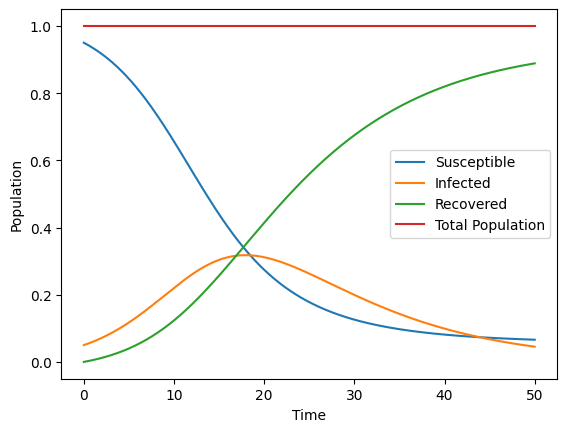

In [25]:
sol = solve_ivp(func, (0, 50), (0.95, 0.05, 0, -3), t_eval=x, method="BDF")
t, y = sol.t, sol.y

plt.plot(t, y[0], label='Susceptible')
plt.plot(t, y[1], label='Infected')
plt.plot(t, y[2], label='Recovered')
plt.plot(t, y[0]+ y[1] + y[2], label='Total Population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()